# Mohd Nizam mohd Nasir Shaikh - 24198170

In [6]:
import yfinance as yf
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.optimize import minimize

In [17]:
data = yf.download(['JPM','BAC','WFC'], start='2020-01-01', end='2026-01-01')
print(data.columns)
data = data['Close']

/tmp/ipython-input-3812250689.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(['JPM','BAC','WFC'], start='2020-01-01', end='2026-01-01')
[*********************100%***********************]  3 of 3 completed


MultiIndex([( 'Close', 'BAC'),
            ( 'Close', 'JPM'),
            ( 'Close', 'WFC'),
            (  'High', 'BAC'),
            (  'High', 'JPM'),
            (  'High', 'WFC'),
            (   'Low', 'BAC'),
            (   'Low', 'JPM'),
            (   'Low', 'WFC'),
            (  'Open', 'BAC'),
            (  'Open', 'JPM'),
            (  'Open', 'WFC'),
            ('Volume', 'BAC'),
            ('Volume', 'JPM'),
            ('Volume', 'WFC')],
           names=['Price', 'Ticker'])


In [9]:

print(data.columns)

Index(['BAC', 'JPM', 'WFC'], dtype='object', name='Ticker')


In [10]:
data

Ticker,BAC,JPM,WFC
Date,,,
2021-01-04,26.613657,110.051910,26.340193
2021-01-05,26.817486,110.650742,27.076303
2021-01-06,28.492474,115.846458,28.991953
2021-01-07,29.121698,119.650734,29.648243
2021-01-08,28.829245,119.782852,29.435389
...,...,...,...
2025-12-24,56.250000,327.691864,94.833908
2025-12-26,56.169998,326.437531,94.794106
2025-12-29,55.349998,322.296204,94.057716


# 1. Decision Tree

In [18]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
import pandas.tseries.offsets as offsets

# Analysis on one currency and prediction for next 1 day

In [20]:
# --- choose ticker ---
ticker = "JPM"

# --- select one series ---
s = data[ticker].sort_index()

# --- create lag features ---
df = pd.DataFrame({"y": s})
df["lag1"] = df["y"].shift(1)
df["lag2"] = df["y"].shift(2)
df["lag3"] = df["y"].shift(3)

# target = next day price
df["target"] = df["y"].shift(-1)
df = df.dropna()

# --- split train/test ---
split = int(len(df) * 0.8)
X_train = df[["lag1", "lag2", "lag3"]].iloc[:split]
y_train = df["target"].iloc[:split]
X_test = df[["lag1", "lag2", "lag3"]].iloc[split:]
y_test = df["target"].iloc[split:]

# --- train model ---
model = DecisionTreeRegressor(random_state=42, max_depth=5)
model.fit(X_train, y_train)

# --- evaluate ---
pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, pred))
print("JPM RMSE:", rmse)

JPM RMSE: 63.77792787668323


In [21]:
# Next day
last_values = df[["lag1", "lag2", "lag3"]].iloc[-1:]
print("JPM Next day:", model.predict(last_values)[0])

JPM Next day: 213.56024169921875


# Prediction for multiple days and multiple currencies.

In [22]:
df_wide = data.sort_index()
df_wide = df_wide.asfreq("B")  # business days
df_wide = df_wide.ffill()
print("Multi-stock ready:", df_wide.columns.tolist())
df_wide.tail()

Multi-stock ready: ['BAC', 'JPM', 'WFC']


Ticker,BAC,JPM,WFC
Date,,,
2025-12-25,56.250000,327.691864,94.833908
2025-12-26,56.169998,326.437531,94.794106
2025-12-29,55.349998,322.296204,94.057716
2025-12-30,55.279999,321.967712,93.848747
2025-12-31,55.000000,320.773071,92.744171


In [23]:
def make_features_one_series(s: pd.Series, horizon: int = 1) -> pd.DataFrame:
    df = pd.DataFrame({"y": s})

    # Lag features
    for lag in [1, 2, 3, 5, 10, 20, 60]:
        df[f"lag_{lag}"] = df["y"].shift(lag)

    # Rolling features
    for w in [5, 10, 20, 60]:
        df[f"roll_mean_{w}"] = df["y"].shift(1).rolling(w).mean()
        df[f"roll_std_{w}"]  = df["y"].shift(1).rolling(w).std()

    # Momentum
    df["ret_1"]  = df["y"].pct_change(1)
    df["ret_5"]  = df["y"].pct_change(5)
    df["ret_20"] = df["y"].pct_change(20)

    # Calendar
    df["dow"] = df.index.dayofweek
    df["month"] = df.index.month

    # Target
    df["target"] = df["y"].shift(-horizon)
    return df.dropna()


In [25]:
def backtest_ticker(prices: pd.Series, horizon: int = 1, n_splits: int = 5):
    data = make_features_one_series(prices, horizon=horizon)
    X = data.drop(columns=["target", "y"])
    y = data["target"]

    tscv = TimeSeriesSplit(n_splits=n_splits)
    model = DecisionTreeRegressor(random_state=42, max_depth=8, min_samples_leaf=10)

    fold_metrics = []
    for fold, (train_idx, test_idx) in enumerate(tscv.split(X), start=1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model.fit(X_train, y_train)
        pred = model.predict(X_test)

        mae = mean_absolute_error(y_test, pred)
        rmse = np.sqrt(mean_squared_error(y_test, pred))
        fold_metrics.append({"fold": fold, "MAE": mae, "RMSE": rmse})

    model.fit(X, y)  # Final model
    return model, pd.DataFrame(fold_metrics), data

In [26]:
models = {}
metrics = {}
for ticker in df_wide.columns:
    print(f"Training {ticker}...")
    model, m, data = backtest_ticker(df_wide[ticker])
    models[ticker] = {"model": model, "data": data}
    metrics[ticker] = m

print("\\nResults:")
for ticker in df_wide.columns:
    print(f"{ticker}: RMSE = {metrics[ticker]['RMSE'].mean():.2f}")

Training BAC...
Training JPM...
Training WFC...
\nResults:
BAC: RMSE = 3.18
JPM: RMSE = 22.58
WFC: RMSE = 6.48


In [28]:
def forecast_next_n_days(prices: pd.Series, trained_model, n_days: int = 20):
    s = prices.copy().asfreq("B").ffill()
    preds = []
    for _ in range(n_days):
        feats = make_features_one_series(s, horizon=1)
        last_row = feats.drop(columns=["target", "y"]).iloc[[-1]]
        yhat = trained_model.predict(last_row)[0]
        next_date = s.index[-1] + offsets.BDay(1)
        s.loc[next_date] = yhat
        preds.append((next_date, yhat))
    return pd.Series(dict(preds)).sort_index()

In [29]:
future_forecasts = {}
for ticker in df_wide.columns:
    future_forecasts[ticker] = forecast_next_n_days(df_wide[ticker], models[ticker]["model"])

print("JPM 20-Day Forecast:")
print(future_forecasts["JPM"].head(10))

JPM 20-Day Forecast:
2026-01-01    322.034384
2026-01-02    322.034384
2026-01-05    322.034384
2026-01-06    322.034384
2026-01-07    322.034384
2026-01-08    322.034384
2026-01-09    322.034384
2026-01-12    322.034384
2026-01-13    322.034384
2026-01-14    322.034384
dtype: float64


In [30]:
df_forecast = pd.DataFrame(future_forecasts)
df_forecast

,BAC,JPM,WFC
2026-01-01,55.338,322.034384,93.530313
2026-01-02,55.338,322.034384,93.530313
2026-01-05,55.338,322.034384,93.530313
2026-01-06,55.338,322.034384,93.530313
2026-01-07,55.338,322.034384,93.530313
2026-01-08,55.338,322.034384,93.530313
2026-01-09,55.338,322.034384,93.530313
2026-01-12,55.338,322.034384,93.530313
2026-01-13,55.338,322.034384,93.530313
2026-01-14,55.338,322.034384,93.530313


# Analysis 1: Sharpe Ratio Portfolio Optimization

In [35]:
daily_returns = df_wide.pct_change()
annualized_returns = daily_returns.mean() * 252
cov_matrix = daily_returns.cov() * 252
daily_returns

Ticker,BAC,JPM,WFC
Date,,,
2020-01-02,NaN,NaN,NaN
2020-01-03,-0.020763,-0.013196,-0.006140
2020-01-06,-0.001433,-0.000795,-0.005990
2020-01-07,-0.006600,-0.017001,-0.008286
2020-01-08,0.010110,0.007801,0.003038
...,...,...,...
2025-12-25,0.000000,0.000000,0.000000
2025-12-26,-0.001422,-0.003828,-0.000420
2025-12-29,-0.014599,-0.012686,-0.007768


In [33]:
def sharpe_ratio(weights, annualized_returns, cov_matrix, risk_free_rate=0.02):
    portfolio_return = np.sum(annualized_returns * weights)
    portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    sharpe_ratio = (portfolio_return - risk_free_rate) / portfolio_volatility
    return -sharpe_ratio  # Negative for minimization

In [36]:
num_assets = len(tickers)
constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
bounds = [(0, 1) for i in range(num_assets)]
initial_weights = [1 / num_assets] * num_assets
result = minimize(sharpe_ratio, initial_weights, args=(annualized_returns, cov_matrix), method='SLSQP', bounds=bounds, constraints=constraints)
optimal_weights = result.x
print("Optimal Weights:", dict(zip(tickers, optimal_weights)))
print("Maximized Sharpe Ratio:", -result.fun)

Optimal Weights: {'JPM': np.float64(0.0), 'BAC': np.float64(0.9999999999999999), 'WFC': np.float64(2.7755575615628914e-16)}
Maximized Sharpe Ratio: 0.6072915275674081


In [37]:
print("Optimal Portfolio Weights:")
for i in range(num_assets):
    print(f"{tickers[i]}: {optimal_weights[i]:.4f}")

Optimal Portfolio Weights:
JPM: 0.0000
BAC: 1.0000
WFC: 0.0000


# Analysis 2: ARIMA Baseline

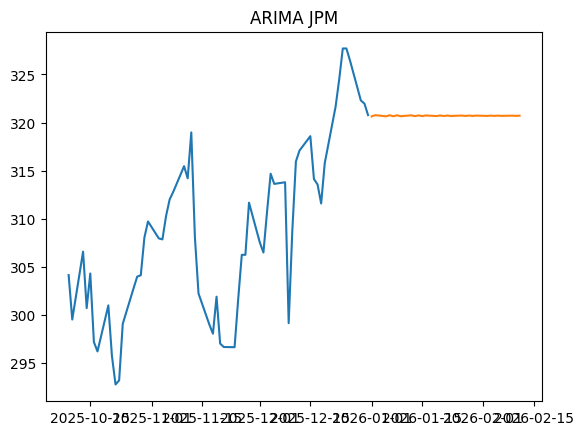

ARIMA Next: 2026-01-01    320.64
2026-01-02    320.76
2026-01-05    320.64
2026-01-06    320.76
2026-01-07    320.65
Freq: B, Name: predicted_mean, dtype: float64


In [50]:
from statsmodels.tsa.arima.model import ARIMA
# Use df_wide instead of data to access the 'JPM' column
model = ARIMA(df_wide['JPM'], order=(1,1,1)).fit()
fc = model.forecast(30)

plt.plot(df_wide['JPM'].tail(60)); plt.plot(fc); plt.title('ARIMA JPM')
plt.show()
print("ARIMA Next:", fc.head().round(2))

# Analysis 3: Bollinger Bands Trading Signals

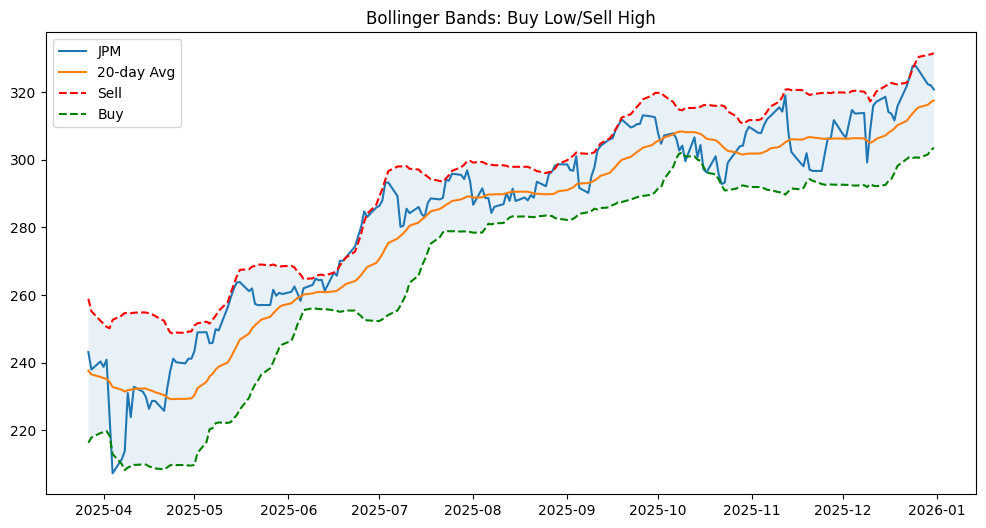

Signals (last 20 days):
BUY signals: 0
SELL signals: 2


In [43]:
jpm = df_wide['JPM']
sma20 = jpm.rolling(20).mean()
std20 = jpm.rolling(20).std()
upper = sma20 + 2*std20
lower = sma20 - 2*std20

plt.figure(figsize=(12,6))
plt.plot(jpm.tail(200), label='JPM')
plt.plot(sma20.tail(200), label='20-day Avg')
plt.plot(upper.tail(200), 'r--', label='Sell')
plt.plot(lower.tail(200), 'g--', label='Buy')
plt.fill_between(jpm.tail(200).index, upper.tail(200), lower.tail(200), alpha=0.1)
plt.legend(); plt.title('Bollinger Bands: Buy Low/Sell High'); plt.show()

recent = jpm.tail(20)
print("Signals (last 20 days):")
print("BUY signals:", (recent < lower.tail(20)).sum())
print("SELL signals:", (recent > upper.tail(20)).sum())

# Analysis 4: Value at Risk (VaR)

$1M Portfolio VaR:
95% VaR (5% worst): $-2896434
99% VaR (1% worst): $-5134535


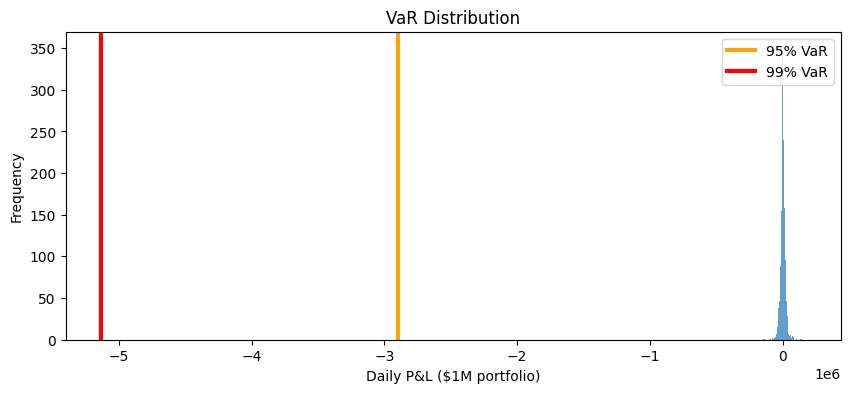

In [46]:
port_ret = daily_ret.dot([0.4, 0.4, 0.2])  # Example weights
worst_5 = np.percentile(port_ret, 5) * 100  # 5% worst day
worst_1 = np.percentile(port_ret, 1) * 100  # 1% worst day

print(f"$1M Portfolio VaR:")
print(f"95% VaR (5% worst): ${worst_5*1000000:.0f}")
print(f"99% VaR (1% worst): ${worst_1*1000000:.0f}")

plt.figure(figsize=(10,4))
plt.hist(port_ret*1000000, bins=50, alpha=0.7)
plt.axvline(worst_5*1000000, color='orange', lw=3, label='95% VaR')
plt.axvline(worst_1*1000000, color='red', lw=3, label='99% VaR')
plt.xlabel('Daily P&L ($1M portfolio)'); plt.ylabel('Frequency')
plt.legend(); plt.title('VaR Distribution'); plt.show()

# 2. XGBoost

In [54]:
from xgboost import XGBRegressor

# Feature engineering
def create_features(series):
    df = pd.DataFrame({'y': series})
    df['lag1'] = df['y'].shift(1)
    df['lag2'] = df['y'].shift(2)
    df['lag3'] = df['y'].shift(3)
    df['ret1'] = df['y'].pct_change(1)
    df['ret5'] = df['y'].pct_change(5)
    df['ma20'] = df['y'].rolling(20).mean()
    df['target'] = df['y'].shift(-1)
    return df.dropna()

# XGBoost for BAC
df = create_features(df_wide['BAC'])
X = df.drop(['y', 'target'], axis=1)
y = df['target']

train_size = int(0.8 * len(X))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

model = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=5)
model.fit(X_train, y_train)

# Predict & evaluate
predictions = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
print('XGBoost BAC RMSE: %.2f' % rmse)

XGBoost BAC RMSE: 5.42


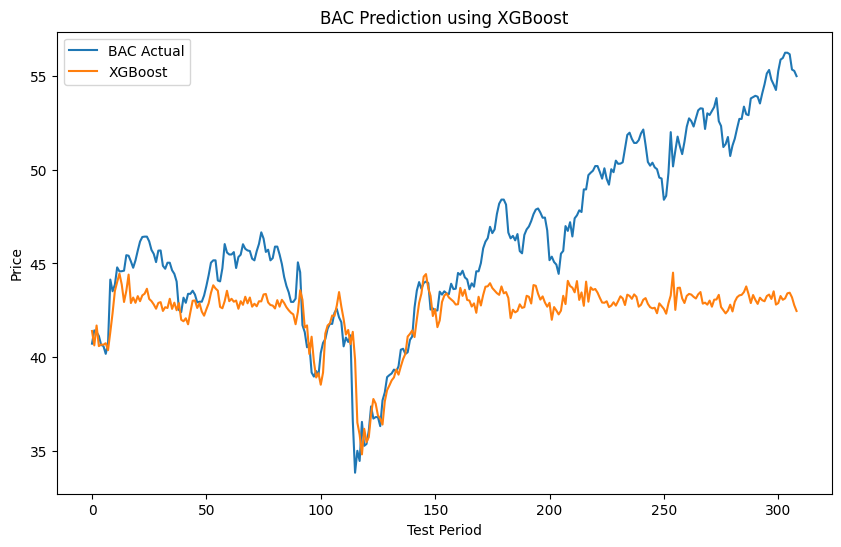

\nTop Features:
lag1: 0.961
lag2: 0.017
lag3: 0.006
ret1: 0.008
ret5: 0.002
ma20: 0.005


In [55]:
# Plot
plt.figure(figsize=(10,6))
plt.plot(range(len(y_test)), y_test.values, label='BAC Actual')
plt.plot(range(len(y_test)), predictions, label='XGBoost')
plt.legend(); plt.title('BAC Prediction using XGBoost')
plt.xlabel('Test Period'); plt.ylabel('Price')
plt.show()

# Feature importance
print("\\nTop Features:")
feature_importance = model.feature_importances_
for i, col in enumerate(X.columns):
    print(f"{col}: {feature_importance[i]:.3f}")

# 3. Linear Regression

Linear Regression BAC RMSE: 0.79

Feature Coefficients:
lag1: 1.0679
lag2: -0.1107
lag3: 0.0330
ret1: 24.7486
ret5: 0.5404
ma20: 0.0065


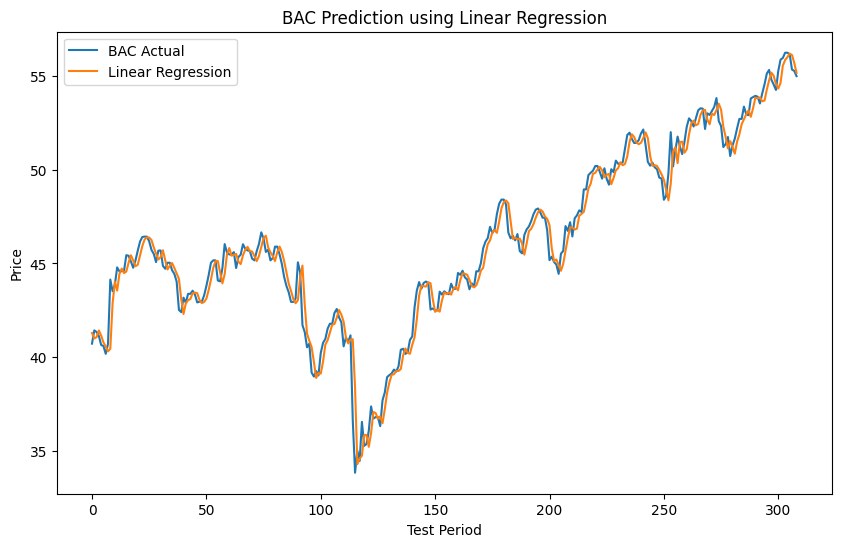

In [63]:
from sklearn.linear_model import LinearRegression

# Same features for BAC
df = create_features(df_wide['BAC'])  # Reuse function above, using df_wide
X = df.drop(['y', 'target'], axis=1)
y = df['target']

train_size = int(0.8 * len(X))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)

# Predict & evaluate
predictions = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
print('Linear Regression BAC RMSE: %.2f' % rmse)

# Feature importance (coefficients)
print("\nFeature Coefficients:")
for i, col in enumerate(X.columns):
    print(f"{col}: {model.coef_[i]:.4f}")

# Plot
plt.figure(figsize=(10,6))
plt.plot(range(len(y_test)), y_test.values, label='BAC Actual')
plt.plot(range(len(y_test)), predictions, label='Linear Regression')
plt.legend(); plt.title('BAC Prediction using Linear Regression')
plt.xlabel('Test Period'); plt.ylabel('Price')
plt.show()

# 4. Corelation Matrix

Correlation Matrix:
Ticker       BAC       JPM       WFC
Ticker                              
BAC     1.000000  0.883141  0.860766
JPM     0.883141  1.000000  0.816365
WFC     0.860766  0.816365  1.000000


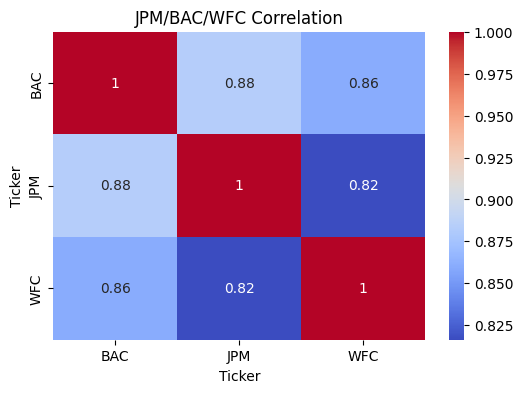

\nDaily Returns Stats:
Ticker          BAC          JPM          WFC
count   1564.000000  1564.000000  1564.000000
mean       0.000597     0.000822     0.000722
std        0.021273     0.019403     0.023273
min       -0.153973    -0.149649    -0.158676
25%       -0.009169    -0.007703    -0.009885
50%        0.000000     0.000344     0.000000
75%        0.010372     0.009519     0.011299
max        0.177962     0.180125     0.145347


In [59]:
# Analyze correlation
correlation_matrix = daily_returns.corr()
print("Correlation Matrix:")
print(correlation_matrix)


plt.figure(figsize=(6,4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('JPM/BAC/WFC Correlation')
plt.show()

# Key statistics
print("\\nDaily Returns Stats:")
print(daily_returns.describe())

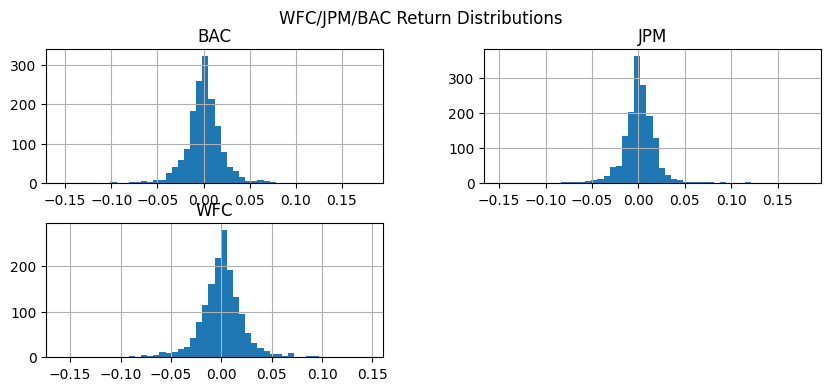

In [70]:
# Histograms
daily_returns.hist(bins=50, figsize=(10,4))
plt.suptitle('WFC/JPM/BAC Return Distributions')
plt.show()

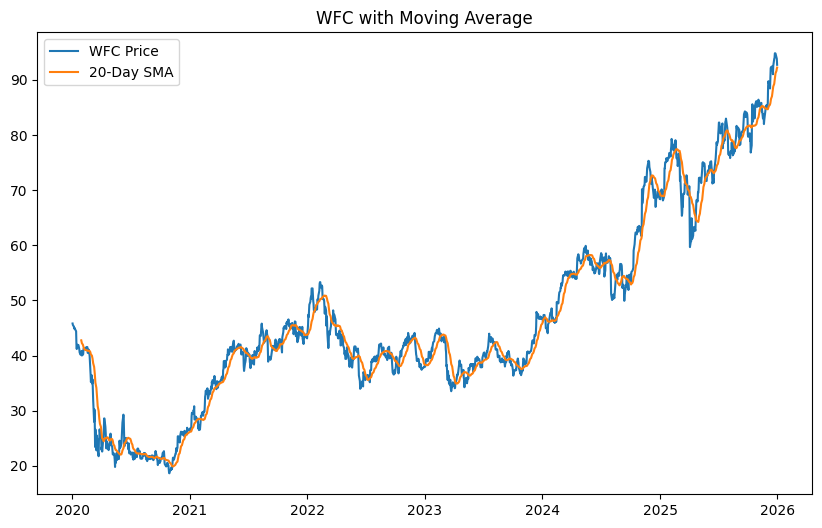

In [71]:
# Moving averages (WFC)
wfc_ma = pd.DataFrame(df_wide['WFC'])
wfc_ma['SMA_20'] = wfc_ma['WFC'].rolling(20).mean()
plt.figure(figsize=(10,6))
plt.plot(wfc_ma.index, wfc_ma['WFC'], label='WFC Price')
plt.plot(wfc_ma.index, wfc_ma['SMA_20'], label='20-Day SMA')
plt.legend(); plt.title('WFC with Moving Average')
plt.show()